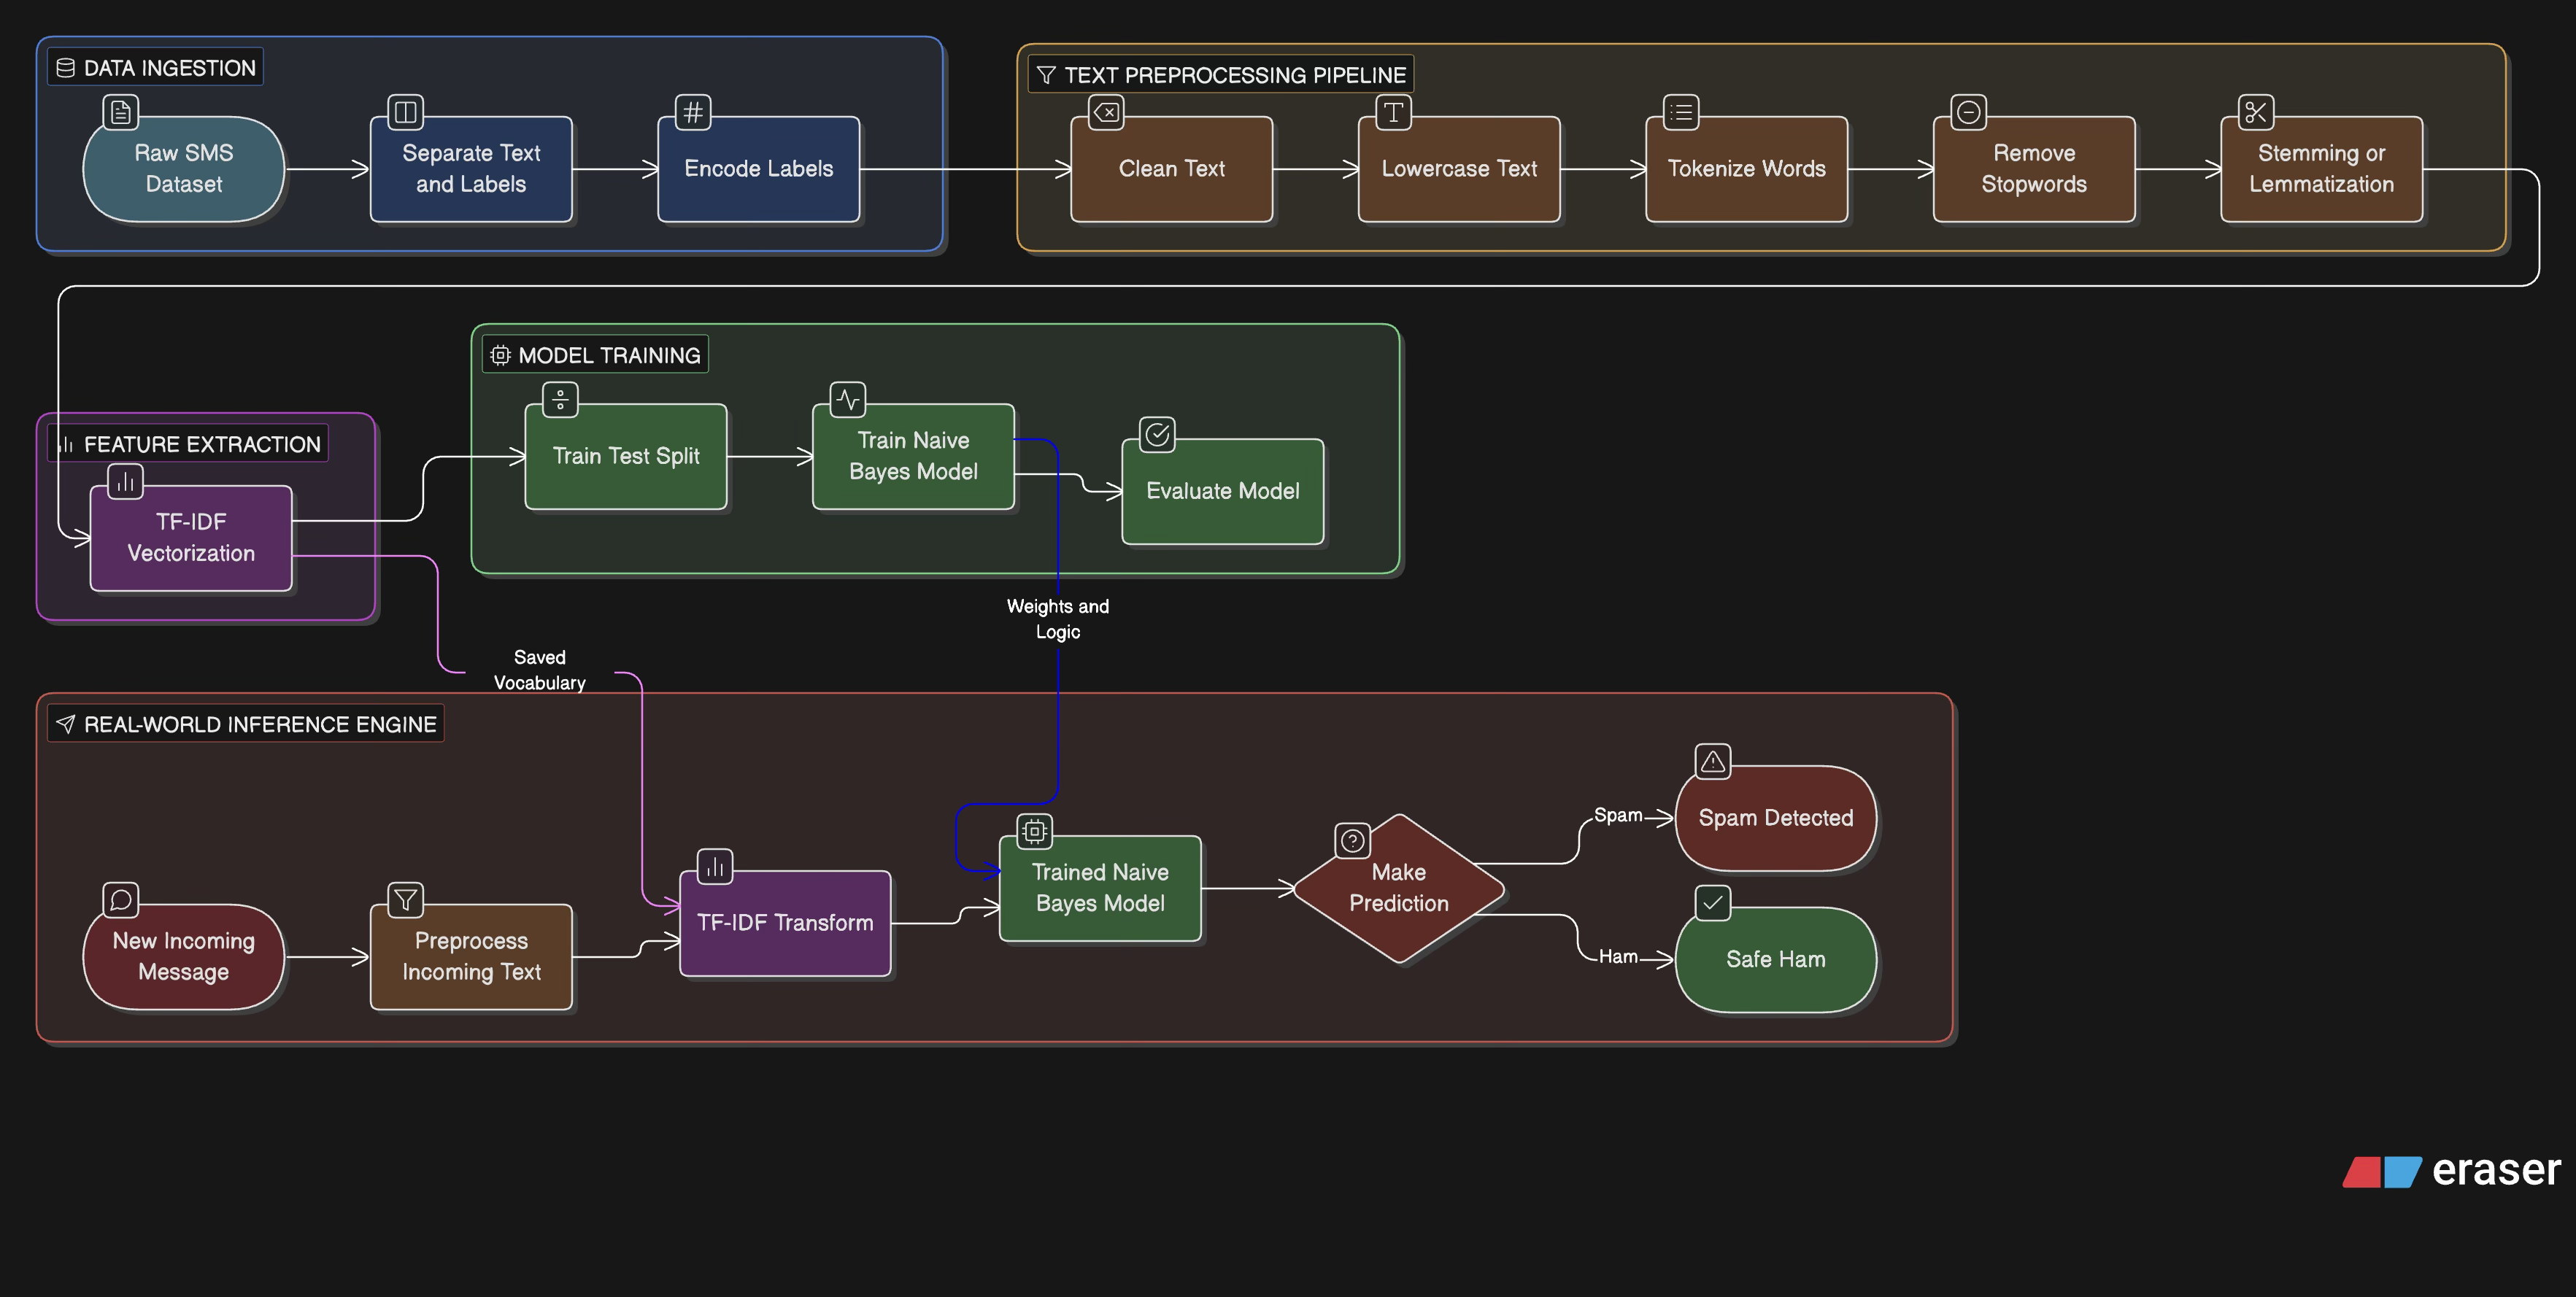

## Step 1: Download the SMS Spam Collection Dataset

Download the SMS Spam Collection dataset from Kaggle using the kagglehub library. This dataset contains SMS messages labeled as either 'ham' (legitimate) or 'spam'.

In [23]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/hrishi/.cache/kagglehub/datasets/uciml/sms-spam-collection-dataset/versions/1


## Step 2: Load and Prepare the Dataset

Load the downloaded CSV file into a pandas DataFrame, rename columns for clarity, and clean up any invalid rows. The dataset contains SMS messages with labels indicating whether each message is spam or legitimate.

In [24]:
import pandas as pd
import os

path2 = os.path.join(path, 'spam.csv')
print("File located at:", path2)

# Load data and rename columns
messages = pd.read_csv(path2, usecols=['v1','v2'], encoding='latin1').rename(columns={'v1': 'label', 'v2': 'message'})

# Clean up any bad rows
messages = messages[messages['label'] != 'v1']

File located at: /Users/hrishi/.cache/kagglehub/datasets/uciml/sms-spam-collection-dataset/versions/1/spam.csv


## Step 3: Import Required Libraries for NLTK

Import the regular expressions (re) module for text cleaning and download NLTK stopwords corpus for filtering common words that don't carry much meaning.

In [32]:
import re
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hrishi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Step 4: Initialize Text Processing Tools

Import NLTK's stopwords corpus and Porter Stemmer. The stopwords will be used to remove common words like "the", "is", "and", while the stemmer reduces words to their root form (e.g., "running" → "run").

In [26]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Initialize the stemmer
ps = PorterStemmer()

## Step 5: Preprocess the SMS Messages

Create a clean corpus by preprocessing each SMS message:
- Remove non-alphabetic characters and replace with spaces
- Convert to lowercase
- Split into individual words
- Apply stemming to reduce words to their root form
- Remove stopwords (common words that don't carry much meaning)
- Rejoin words into cleaned text strings

In [27]:
corpus = []

for i in range(0, len(messages)):
    # Replace non-alphabetic characters with space
    review = re.sub('[^a-zA-Z]', ' ', messages['message'].iloc[i]) 
    
    # Convert to lowercase
    review = review.lower()
    
    # Split into words
    review = review.split()
    
    # Stem words and remove stopwords
    review = [ps.stem(word) for word in review if word not in stopwords.words("english")]
    
    # Rejoin into a single string
    review = ' '.join(review)
    
    corpus.append(review)

print("Sample of preprocessed text:")
print(corpus[:5])

Sample of preprocessed text:
['go jurong point crazi avail bugi n great world la e buffet cine got amor wat', 'ok lar joke wif u oni', 'free entri wkli comp win fa cup final tkt st may text fa receiv entri question std txt rate c appli', 'u dun say earli hor u c alreadi say', 'nah think goe usf live around though']


## Step 6: Convert Text to Numerical Features (TF-IDF)

Transform the preprocessed text corpus into numerical feature vectors using TF-IDF (Term Frequency-Inverse Document Frequency):
- TF-IDF weighs words by how important they are to a document relative to the entire corpus
- Convert categorical labels ('ham'/'spam') to numerical format (0/1)
- Limit to top 2500 features to reduce dimensionality

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Convert text to TF-IDF features
tfidf = TfidfVectorizer(max_features=2500)
X = tfidf.fit_transform(corpus).toarray()

# 2. Convert labels to numerical format: 'ham' -> 0, 'spam' -> 1
y = pd.get_dummies(messages['label'], drop_first=True).values.ravel()

print(f"Feature matrix shape: {X.shape}")
print(f"Target array shape: {y.shape}")

Feature matrix shape: (5572, 2500)
Target array shape: (5572,)


## Step 7: Split Data into Training and Testing Sets

Divide the dataset into training and testing subsets:
- 80% of data for training the model
- 20% of data for evaluating model performance
- Use random_state=0 for reproducible results

In [29]:
from sklearn.model_selection import train_test_split

# Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (4457, 2500)
Testing data shape: (1115, 2500)


## Step 8: Train and Evaluate the Spam Detection Model

Train a Multinomial Naive Bayes classifier on the training data and evaluate its performance:
- Naive Bayes is effective for text classification tasks
- Evaluate using accuracy score, confusion matrix, and detailed classification report
- The confusion matrix shows true positives, false positives, true negatives, and false negatives

In [30]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Initialize and train the model
spam_detect_model = MultinomialNB()
spam_detect_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = spam_detect_model.predict(X_test)

# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.9721973094170404

Confusion Matrix:
 [[948   1]
 [ 30 136]]

Classification Report:
               precision    recall  f1-score   support

       False       0.97      1.00      0.98       949
        True       0.99      0.82      0.90       166

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.97      0.97      0.97      1115



## Step 9: Create Prediction Function and Test the Model

Create a reusable function to classify new SMS messages as spam or ham:
- Apply the same preprocessing steps used during training
- Transform text using the trained TF-IDF vectorizer
- Make predictions using the trained Naive Bayes model
- Test the function with sample messages including both spam and legitimate examples

In [31]:
def predict_spam(input_text):
    # 1. Clean and preprocess the input text
    review = re.sub('[^a-zA-Z]', ' ', input_text)
    review = review.lower()
    review = review.split()
    
    # Use the PorterStemmer initialized earlier
    review = [ps.stem(word) for word in review if word not in stopwords.words("english")]
    review = ' '.join(review)
    
    # 2. Convert to TF-IDF vector using the already fitted tfidf object
    vectorized_input = tfidf.transform([review]).toarray()
    
    # 3. Make the prediction
    prediction = spam_detect_model.predict(vectorized_input)
    
    # 4. Output the result
    if prediction[0] == 1:
        return f"🚨 SPAM DETECTED: '{input_text}'"
    else:
        return f"✅ SAFE (Ham): '{input_text}'"

# --- Test the Inference Mechanism ---
print(predict_spam("URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010"))
print(predict_spam("Hey man, are we still meeting up for lunch today?"))
print(predict_spam("Congratulations! Your credit score qualifies you for a free personal loan. Click here to claim."))

🚨 SPAM DETECTED: 'URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010'
✅ SAFE (Ham): 'Hey man, are we still meeting up for lunch today?'
🚨 SPAM DETECTED: 'Congratulations! Your credit score qualifies you for a free personal loan. Click here to claim.'
